In [4]:
!pip install -q -U datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 19.2 MB/s eta 0:00:00


In [5]:
from datasets import load_dataset
ds = load_dataset("risqaliyevds/uzbek_ner")
print (ds)

README.md:   0%|          | 0.00/3.05k [00:00<?, ?B/s]

uzbek_ner.json:   0%|          | 0.00/24.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/19609 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['ner', 'text'],
        num_rows: 19609
    })
})


In [6]:
train = ds["train"]

row = train[0]
print(row["text"])
print()
print(row["ner"])

Shvetsiya hukumati Stokholmdagi asosiy piyodalar ko‘chasi Drottninggatanda odamlar ustiga yuk mashinasini haydab borgani gumon qilinayotgan shaxsni qo‘lga oldi. Bu haqda Expressen TV efirida Shvetsiya bosh vaziri Stefan Lyoven ma'lum qildi. Ushbu shaxs surati ijtimoiy tarmoqda tarqalmoqda. U Spendrups kompaniyasiga tegishli yuk mashinasini o‘g‘irlagani aytilmoqda.   Oxirgi ma'lumotlarga ko‘ra, ushbu hujum oqibatida halok bo‘lganlar soni 5 nafarga yetdi, jarohatlanganlar soni aniq emas.

{'CARDINAL': None, 'DATE': None, 'EMAIL': None, 'EVENT': None, 'FAC': None, 'FACILITY': None, 'GPE': ['Shvetsiya', 'O‘zbekiston', 'Shvetsiya bosh vaziri Stefan Lyoven'], 'JCH-2022': None, 'JOURNAL': None, 'LANGUAGE': None, 'LAW': None, 'LOC': ['Drottninggatanda', 'Stokholmdagi'], 'MISC': None, 'MONEY': None, 'NORP': None, 'ORDINAL': None, 'ORG': ['Spendrups kompaniyasi'], 'PER': None, 'PERCENT': None, 'PERIOD': None, 'PERSON': ['Shvetsiya bosh vaziri Stefan Lyoven'], 'PHONE': None, 'PRODUCT': None, 'QUA

In [7]:
def entities_of(row):
  return {k: v for k, v in row["ner"].items() if v}

for i in range(5):
  r = train[i]
  print(f"--- Row {i} ---")
  print("TEXT:", r["text"][:250])
  print("ENTITIES:", entities_of(r))
  print()

--- Row 0 ---
TEXT: Shvetsiya hukumati Stokholmdagi asosiy piyodalar ko‘chasi Drottninggatanda odamlar ustiga yuk mashinasini haydab borgani gumon qilinayotgan shaxsni qo‘lga oldi. Bu haqda Expressen TV efirida Shvetsiya bosh vaziri Stefan Lyoven ma'lum qildi. Ushbu sha
ENTITIES: {'GPE': ['Shvetsiya', 'O‘zbekiston', 'Shvetsiya bosh vaziri Stefan Lyoven'], 'LOC': ['Drottninggatanda', 'Stokholmdagi'], 'ORG': ['Spendrups kompaniyasi'], 'PERSON': ['Shvetsiya bosh vaziri Stefan Lyoven']}

--- Row 1 ---
TEXT: Turkiya prezidenti Rajab Toyyib Erdo‘g‘an AQSh qurolli kuchlarining Suriyadagi aviabazaga hujumini "Suriya xalqini himoyalash uchun" yetarlicha bo‘lmaganini aytdi. Bu haqda Reuters axborot agentligi xabar bermoqda. "Biz Asad tuzumi harbiy jinoyatlari
ENTITIES: {'DATE': [''], 'GPE': ['O‘zbekiston', 'Suriya', 'AQSh', 'Vashington'], 'LOC': ['Suriya', 'Shayrat aerodromi'], 'ORG': ['AQSh qurolli kuchlari'], 'PERSON': ['Rajab Toyyib Erdo‘g‘an', 'Jan-Klod Yunker']}

--- Row 2 ---
TEXT: Stokhol

In [10]:
import random
random.seed(42)

for i in random.sample(range(len(train)), 3):
  r = train[i]
  print(f"--- Row {i} ---")
  print("TEXT:", r["text"][:250])
  print("ENTITIES:", entities_of(r))
  print()

--- Row 3648 ---
TEXT: XXR Xalq banki (markaziy banki) mamlakat milliy valyutasi jenminbi (yuanning rasmiy nomi)ning dollarga nisbatan kursini 153 punktga tushirdi. Endilikda,  bir dollar 6,6528 yuanga tengdir. Bu so‘nggi 6 yildagi eng past ko‘rsatkichdir. China Securities
ENTITIES: {'GPE': ['O‘zbekiston', 'Buyuk Britaniya'], 'LOC': ['Yuanning'], 'MONEY': ['bir dollar', '6,6528 yuanga', '153 punkt'], 'ORG': ['XXR Xalq banki', 'China Securities sarmoya kompaniyasi', 'Industrial bank'], 'PERSON': ['Chjen Tszaoshun', 'Lu Chjenvey']}

--- Row 819 ---
TEXT: O‘zbekistonning turli hududlarida epimarkazi Tojikistonda joylashgan zilzila kuchi sezildi. Toshkentda yer silkinishi kuchi 4 ballga teng bo‘ldi. FVV Seysmoprognostik monitoring Respublika markazi xabariga ko‘ra, Toshkent vaqti bilan 09:44da O‘zbekis
ENTITIES: {'GPE': ['O‘zbekiston', 'Tojikistonda'], 'LOC': ['O‘zbekiston-Tojikiston chegarasida'], 'ORG': ['XDP']}

--- Row 9012 ---
TEXT: Rossiya IShIDning Suriyadagi pozitsiyalariga jiddiy 

In [11]:
all_keys = sorted(train[0]["ner"].keys())
print(len(all_keys), "categories in the schema:")
print(all_keys)

29 categories in the schema:
['CARDINAL', 'DATE', 'EMAIL', 'EVENT', 'FAC', 'FACILITY', 'GPE', 'JCH-2022', 'JOURNAL', 'LANGUAGE', 'LAW', 'LOC', 'MISC', 'MONEY', 'NORP', 'ORDINAL', 'ORG', 'PER', 'PERCENT', 'PERIOD', 'PERSON', 'PHONE', 'PRODUCT', 'QUANTITY', 'RASUM', 'SOCIAL_MEDIA', 'TIME', 'WEBSITE', 'WORK_OF_ART']


In [17]:
from collections import Counter

rows_with = Counter()
total_strings = Counter()
junk_strings = Counter()

for rown in train:
  for cat, vals in row["ner"].items():
    if vals is None:
      continue
    clean = [v for v in vals if isinstance(v, str) and v.strip()]
    junk_strings[cat] += len(vals) - len(clean)
    if clean:
      rows_with[cat] +=1
      total_strings[cat] += len(clean)

In [18]:
import pandas as pd

tbl = pd.DataFrame({
    "rows_with_category": pd.Series(rows_with),
    "total_entity_strings": pd.Series(total_strings),
    "junk_strings": pd.Series(junk_strings),
}).fillna(0).astype(int)

tbl["pct_of_rows"]=(tbl["rows_with_category"] / len(train) * 100).round(1)
tbl = tbl.sort_values("total_entity_strings", ascending=False)
print(tbl.to_string())

        rows_with_category  total_entity_strings  junk_strings  pct_of_rows
GPE                  19609                 58827             0        100.0
LOC                  19609                 39218             0        100.0
ORG                  19609                 19609             0        100.0
PERSON               19609                 19609             0        100.0


In [19]:
# 1. For ONE row, show the raw type and content of every category
row = train[0]
for cat, vals in row["ner"].items():
    print(f"{cat:12} type={type(vals).__name__:6} value={repr(vals)[:120]}")

CARDINAL     type=NoneType value=None
DATE         type=NoneType value=None
EMAIL        type=NoneType value=None
EVENT        type=NoneType value=None
FAC          type=NoneType value=None
FACILITY     type=NoneType value=None
GPE          type=list   value=['Shvetsiya', 'O‘zbekiston', 'Shvetsiya bosh vaziri Stefan Lyoven']
JCH-2022     type=NoneType value=None
JOURNAL      type=NoneType value=None
LANGUAGE     type=NoneType value=None
LAW          type=NoneType value=None
LOC          type=list   value=['Drottninggatanda', 'Stokholmdagi']
MISC         type=NoneType value=None
MONEY        type=NoneType value=None
NORP         type=NoneType value=None
ORDINAL      type=NoneType value=None
ORG          type=list   value=['Spendrups kompaniyasi']
PER          type=NoneType value=None
PERCENT      type=NoneType value=None
PERIOD       type=NoneType value=None
PERSON       type=list   value=['Shvetsiya bosh vaziri Stefan Lyoven']
PHONE        type=NoneType value=None
PRODUCT      type=Non

In [20]:
# 2. Across all rows: what Python types does each category actually hold?
from collections import defaultdict
types_seen = defaultdict(set)
sample_val = {}
for row in train:
    for cat, vals in row["ner"].items():
        if vals is None:
            continue
        for v in vals:                      # vals is a list; inspect its elements
            types_seen[cat].add(type(v).__name__)
            if cat not in sample_val:
                sample_val[cat] = v          # keep one real example per category
for cat in sorted(types_seen):
    print(f"{cat:12} element_types={types_seen[cat]}  example={repr(sample_val[cat])[:100]}")

CARDINAL     element_types={'str'}  example=''
DATE         element_types={'str'}  example=''
EMAIL        element_types={'str'}  example='admin@tiiame.uz'
EVENT        element_types={'str'}  example='terakt'
FAC          element_types={'str'}  example='Mangawhai Locals Facebook Page'
FACILITY     element_types={'str'}  example="Tartus portidagi moddiy-texnik ta'minot punkti"
GPE          element_types={'str'}  example='Shvetsiya'
JCH-2022     element_types={'str'}  example='JCh-2022'
JOURNAL      element_types={'str'}  example='Annals of Internal Medicine'
LANGUAGE     element_types={'str'}  example=''
LAW          element_types={'str'}  example='O‘zbekiston Respublikasi Qonun hujjatlari'
LOC          element_types={'str'}  example='Drottninggatanda'
MISC         element_types={'str'}  example='FVV Seysmoprognostik'
MONEY        element_types={'str'}  example='110 milliard dollar'
NORP         element_types={'str'}  example='musulmonlar'
ORDINAL      element_types={'str'}  example=''


In [21]:
from collections import Counter

# Merge duplicate label schemes into canonical names
CANON = {
    "PER": "PERSON", "PERSON": "PERSON",
    "GPE": "GPE",
    "LOC": "LOC",
    "ORG": "ORG",
    "FAC": "FAC", "FACILITY": "FAC",
    "PERIOD": "DATE", "DATE": "DATE",       # PERIOD is holding real dates
}
# Keys that are clearly noise — exclude entirely
JUNK_KEYS = {"JCH-2022", "RASUM", "MISC"}

rows_with = Counter()
total_strings = Counter()

for row in train:
    seen_this_row = set()
    for cat, vals in row["ner"].items():
        if vals is None or cat in JUNK_KEYS:
            continue
        name = CANON.get(cat, cat)          # map to canonical, else keep original
        clean = [v for v in vals if isinstance(v, str) and v.strip()]
        if clean:
            total_strings[name] += len(clean)
            if name not in seen_this_row:
                rows_with[name] += 1
                seen_this_row.add(name)

import pandas as pd
tbl = pd.DataFrame({
    "rows_with_category": pd.Series(rows_with),
    "total_entity_strings": pd.Series(total_strings),
}).fillna(0).astype(int)
tbl["pct_of_rows"] = (tbl["rows_with_category"] / len(train) * 100).round(1)
tbl = tbl.sort_values("total_entity_strings", ascending=False)
print(tbl.to_string())

              rows_with_category  total_entity_strings  pct_of_rows
GPE                        19503                 50036         99.5
LOC                        18898                 38751         96.4
ORG                        18141                 28244         92.5
PERSON                     11996                 25044         61.2
DATE                        6069                 10940         31.0
MONEY                       2200                  5699         11.2
FAC                         2811                  3674         14.3
EVENT                       2676                  3403         13.6
PRODUCT                     1073                  2397          5.5
PERCENT                      396                  1083          2.0
QUANTITY                     296                  1075          1.5
TIME                         509                   933          2.6
CARDINAL                     109                   455          0.6
NORP                         309                

In [22]:
# Confirm PERIOD really holds dates (not durations/periods of time)
period_vals = []
for row in train:
    v = row["ner"].get("PERIOD")
    if v:
        period_vals += [x for x in v if isinstance(x, str) and x.strip()]
print("PERIOD sample:", period_vals[:25])
print("PERIOD count:", len(period_vals))

PERIOD sample: ['19 iyul', 'avgust boshlarida', '2018 yil', '2019 yili', '15 dekabr', '2011 yil', '2018 yil', '20 dekabr kuni']
PERIOD count: 8


In [23]:
# Confirm PER and PERSON aren't double-labeling the SAME span in a row
both = sum(1 for row in train
           if (row["ner"].get("PER")) and (row["ner"].get("PERSON")))
print("rows where PER and PERSON both fire:", both)

rows where PER and PERSON both fire: 0


In [24]:
for key in ["DATE", "PERIOD", "TIME"]:
    rows = 0
    strings = 0
    empties = 0
    example = []
    for row in train:
        v = row["ner"].get(key)
        if not v:
            continue
        clean = [x for x in v if isinstance(x, str) and x.strip()]
        empties += sum(1 for x in v if isinstance(x, str) and not x.strip())
        if clean:
            rows += 1
            strings += len(clean)
            if len(example) < 12:
                example += clean[:12 - len(example)]
    print(f"{key:8} rows={rows:6}  strings={strings:6}  empty_strings={empties:5}  e.g. {example[:12]}")

DATE     rows=  6065  strings= 10932  empty_strings=  206  e.g. ['2015 yil', 'ikki kun', 'oldinroq', '7 aprel', '4 aprel', '7 aprel', "hali ma'lum", '7 aprel', '4 aprel', '7 aprel', '7 aprel', '4 aprel kuni']
PERIOD   rows=     4  strings=     8  empty_strings=    0  e.g. ['19 iyul', 'avgust boshlarida', '2018 yil', '2019 yili', '15 dekabr', '2011 yil', '2018 yil', '20 dekabr kuni']
TIME     rows=   509  strings=   933  empty_strings=   99  e.g. ['17:30', '—', '4-daqiqasida', '90+2', '49-daqiqasida', '7:00', '20:00', 'erta tongda', '08:00', '22:00', '10-11 daqiqa', '07:50']


In [25]:
import numpy as np

chars = [len(t) for t in train["text"]]
words = [len(t.split()) for t in train["text"]]

print ("characters: min", np.min(chars),
       " p50/p90/p99", np.percentile(chars, [50, 90, 99]).astype(int),
" max", np.max(chars))
print("words: min", np.min(words),
" p50/p90/p99", np.percentile(words, [50, 90, 99]).astype(int),
" max", np.max(words))

characters: min 87  p50/p90/p99 [737 944 994]  max 999
words: min 10  p50/p90/p99 [ 89 114 128]  max 159


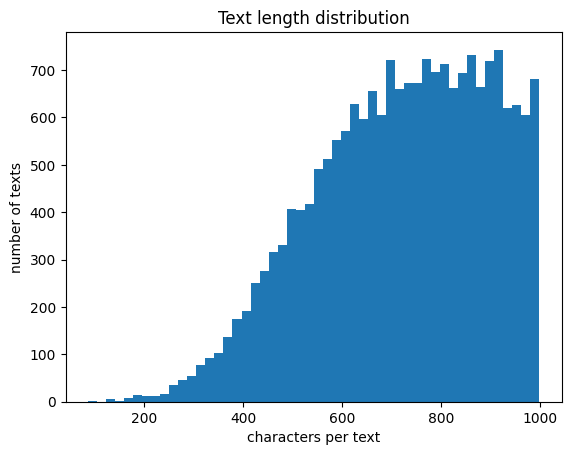

In [26]:
import matplotlib.pyplot as plt
plt.hist(chars, bins=50)
plt.xlabel("characters per text")
plt.ylabel("number of texts")
plt.title("Text length distribution")
plt.show()

In [28]:
from collections import Counter
import pandas as pd
# Final canonical mapping — PERIOD is deliberately NOT merged anywhere.
CANON = {
"PER": "PERSON", "PERSON": "PERSON",
"GPE": "GPE",
"LOC": "LOC",
"ORG": "ORG",
"FAC": "FAC", "FACILITY": "FAC",
"DATE": "DATE",
}
JUNK_KEYS = {"JCH-2022", "RASUM", "MISC"}
rows_with = Counter()
total_strings = Counter()
for row in train:
    seen_this_row = set()
    for cat, vals in row["ner"].items():
        if vals is None or cat in JUNK_KEYS:
            continue
        name = CANON.get(cat, cat)
        clean = [v for v in vals if isinstance(v, str) and v.strip()]
        if clean:
            total_strings[name] += len(clean)
            if name not in seen_this_row:
                rows_with[name] += 1
                seen_this_row.add(name)
tbl = pd.DataFrame({
"rows_with_category": pd.Series(rows_with),
"total_entity_strings": pd.Series(total_strings),
}).fillna(0).astype(int)
tbl["pct_of_rows"] = (tbl["rows_with_category"] / len(train) *
100).round(1)
tbl = tbl.sort_values("total_entity_strings", ascending=False)
print(tbl.to_string())

              rows_with_category  total_entity_strings  pct_of_rows
GPE                        19503                 50036         99.5
LOC                        18898                 38751         96.4
ORG                        18141                 28244         92.5
PERSON                     11996                 25044         61.2
DATE                        6065                 10932         30.9
MONEY                       2200                  5699         11.2
FAC                         2811                  3674         14.3
EVENT                       2676                  3403         13.6
PRODUCT                     1073                  2397          5.5
PERCENT                      396                  1083          2.0
QUANTITY                     296                  1075          1.5
TIME                         509                   933          2.6
CARDINAL                     109                   455          0.6
NORP                         309                

In [30]:
top5 = ["GPE", "LOC", "ORG", "PERSON", "DATE"]
share = tbl.loc[top5, "total_entity_strings"].sum() / tbl["total_entity_strings"].sum() * 100
print(round(share, 1), "%")

88.3 %


In [31]:
tbl.to_csv("phase1_category_frequency.csv")
print("saved")

saved


In [34]:
row = train[0]
for cat, vals in row["ner"].items():
    print(f"{cat:12} type={type(vals).__name__:8} value={repr(vals) [:100]}")

CARDINAL     type=NoneType value=None
DATE         type=NoneType value=None
EMAIL        type=NoneType value=None
EVENT        type=NoneType value=None
FAC          type=NoneType value=None
FACILITY     type=NoneType value=None
GPE          type=list     value=['Shvetsiya', 'O‘zbekiston', 'Shvetsiya bosh vaziri Stefan Lyoven']
JCH-2022     type=NoneType value=None
JOURNAL      type=NoneType value=None
LANGUAGE     type=NoneType value=None
LAW          type=NoneType value=None
LOC          type=list     value=['Drottninggatanda', 'Stokholmdagi']
MISC         type=NoneType value=None
MONEY        type=NoneType value=None
NORP         type=NoneType value=None
ORDINAL      type=NoneType value=None
ORG          type=list     value=['Spendrups kompaniyasi']
PER          type=NoneType value=None
PERCENT      type=NoneType value=None
PERIOD       type=NoneType value=None
PERSON       type=list     value=['Shvetsiya bosh vaziri Stefan Lyoven']
PHONE        type=NoneType value=None
PRODUCT      

In [36]:
from collections import defaultdict
types_seen = defaultdict(set)
sample_val = {}
for row in train:
    for cat, vals in row["ner"].items():
        if vals is None:
            continue
        for v in vals:
            types_seen[cat].add(type(v).__name__)
            if cat not in sample_val:
                sample_val[cat] = v
for cat in sorted(types_seen):
    print(f"{cat:12} element_types={types_seen[cat]} example={repr(sample_val[cat])[:100]}")

CARDINAL     element_types={'str'} example=''
DATE         element_types={'str'} example=''
EMAIL        element_types={'str'} example='admin@tiiame.uz'
EVENT        element_types={'str'} example='terakt'
FAC          element_types={'str'} example='Mangawhai Locals Facebook Page'
FACILITY     element_types={'str'} example="Tartus portidagi moddiy-texnik ta'minot punkti"
GPE          element_types={'str'} example='Shvetsiya'
JCH-2022     element_types={'str'} example='JCh-2022'
JOURNAL      element_types={'str'} example='Annals of Internal Medicine'
LANGUAGE     element_types={'str'} example=''
LAW          element_types={'str'} example='O‘zbekiston Respublikasi Qonun hujjatlari'
LOC          element_types={'str'} example='Drottninggatanda'
MISC         element_types={'str'} example='FVV Seysmoprognostik'
MONEY        element_types={'str'} example='110 milliard dollar'
NORP         element_types={'str'} example='musulmonlar'
ORDINAL      element_types={'str'} example=''
ORG          ele

Phase 2